In [ ]:
!pip install earthengine-api geemap

**Initialization cell for Google Earth Engine (GEE)**

In [ ]:
import ee
import geemap

ee.Authenticate()

ee.Initialize(project='da-project-492516')

**Visualization setup cell**

In [ ]:
Map = geemap.Map(center=[28.6, 77.2], zoom=10)  # Delhi
Map

Map(center=[28.6, 77.2], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

**Region of Interest**

In [ ]:
roi = ee.Geometry.Rectangle([77.0, 28.4, 77.5, 28.9])

**Core data pipeline**

In [ ]:
dataset = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(roi)
    .filterDate('2023-04-01', '2023-06-30')  # summer
    .filterMetadata('CLOUD_COVER', 'less_than', 10)
    .median()
)

In [ ]:
dataset

**NDVI (Normalized Difference Vegetation Index)**

In [ ]:
ndvi = dataset.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

Map.addLayer(ndvi,
             {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'green']},
             'NDVI')

In [ ]:
ndvi

**NDBI (Normalized Difference Built-up Index)**

In [ ]:
ndbi = dataset.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

Map.addLayer(ndbi,
             {'min': -1, 'max': 1, 'palette': ['green', 'white', 'brown']},
             'NDBI')

In [ ]:
ndbi

**Land Surface Temperature (LST)**

In [ ]:
lst = dataset.select('ST_B10') \
    .multiply(0.00341802) \
    .add(149.0) \
    .subtract(273.15) \
    .rename('LST')

Map.addLayer(lst,
             {'min': 20, 'max': 45, 'palette': ['blue', 'yellow', 'red']},
             'LST')

**move from raw temperature to a derived index (UHI) using normalization**

In [ ]:
stats = lst.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=roi,
    scale=30,
    maxPixels=1e9
)

lst_min = ee.Number(stats.get('LST_min'))
lst_max = ee.Number(stats.get('LST_max'))

uhi = lst.subtract(lst_min).divide(lst_max.subtract(lst_min)).rename('UHI')

Map.addLayer(uhi,
             {'min': 0, 'max': 1, 'palette': ['blue', 'yellow', 'red']},
             'UHI')

In [ ]:
Map

Map(center=[28.6, 77.2], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

**pure remote sensing → data preparation for ML/statistical analysis**

In [ ]:
combined = lst.addBands(ndvi).addBands(ndbi)

samples = combined.sample(
    region=roi,
    scale=30,
    numPixels=1000,
    geometries=False
)

In [ ]:
import pandas as pd

data = samples.getInfo()

df = pd.DataFrame([f['properties'] for f in data['features']])

df.head()

,LST,NDBI,NDVI
0,40.267016,-0.005793,0.224999
1,41.453069,0.031274,0.163369
2,38.881009,-0.049121,0.198954
3,37.737681,-0.173365,0.345331
4,40.613945,-0.024746,0.167782


I converted the sampled Earth Engine FeatureCollection into a Pandas DataFrame using getInfo() to enable local analysis and machine learning.

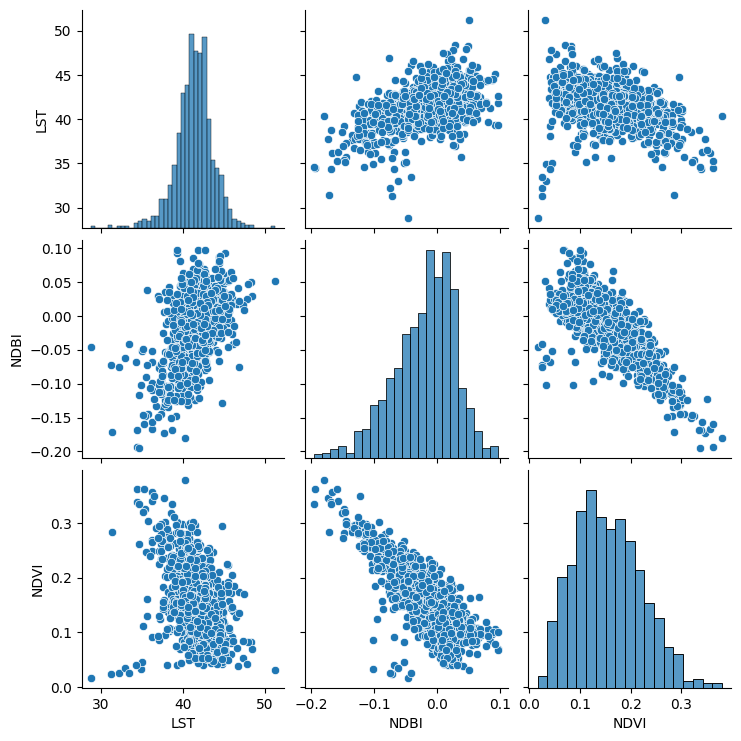

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

In [ ]:
df = df.dropna()

# Features and target
X = df[['NDVI', 'NDBI']]
y = df['LST']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Linear Regression:
MAE: 1.4688974322160298
R2 Score: 0.20419251878823175

Random Forest:
MAE: 1.4482311386940003
R2 Score: 0.3179251050450702


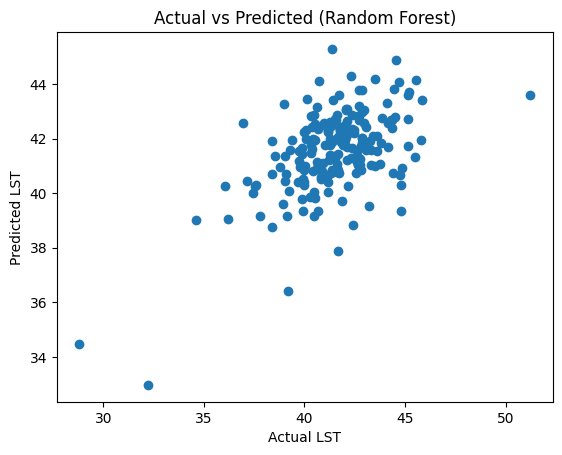

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

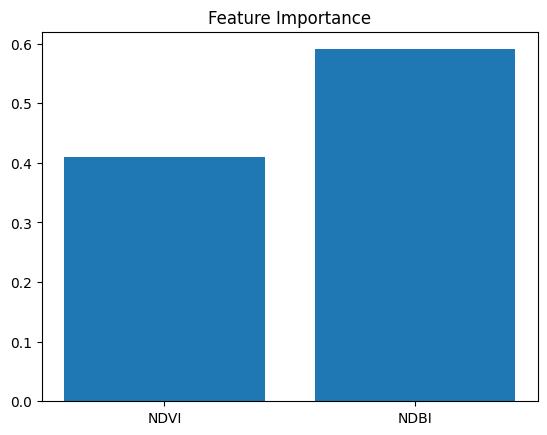

In [ ]:
import pandas as pd

importance = rf.feature_importances_
features = ['NDVI', 'NDBI']

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

In [ ]:
def process_year(year):
    start = f"{year}-04-01"
    end = f"{year}-06-30"

    dataset = (
        ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(roi)
        .filterDate(start, end)
        .filterMetadata('CLOUD_COVER', 'less_than', 10)
        .median()
    )

    # NDVI
    ndvi = dataset.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

    # NDBI
    ndbi = dataset.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

    # LST
    lst = dataset.select('ST_B10') \
        .multiply(0.00341802) \
        .add(149.0) \
        .subtract(273.15) \
        .rename('LST')

    # Mean values
    stats = lst.addBands(ndvi).addBands(ndbi).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=30,
        maxPixels=1e9
    )

    return ee.Feature(None, {
        'year': year,
        'LST': stats.get('LST'),
        'NDVI': stats.get('NDVI'),
        'NDBI': stats.get('NDBI')
    })

In [ ]:
years = list(range(2015, 2024))

features = [process_year(y) for y in years]

fc = ee.FeatureCollection(features)

In [ ]:
data = fc.getInfo()

df_time = pd.DataFrame([f['properties'] for f in data['features']])

df_time

,LST,NDBI,NDVI,year
0,43.227133,-0.001162,0.128846,2015
1,42.087227,0.002536,0.112527,2016
2,43.125386,0.001706,0.121290,2017
3,45.966845,0.006180,0.115884,2018
4,47.674038,-0.002548,0.130389,2019
5,42.046667,-0.016519,0.146305,2020
6,40.832571,-0.008925,0.132130,2021
7,41.872671,-0.020054,0.142376,2022
8,41.311895,-0.021126,0.160145,2023


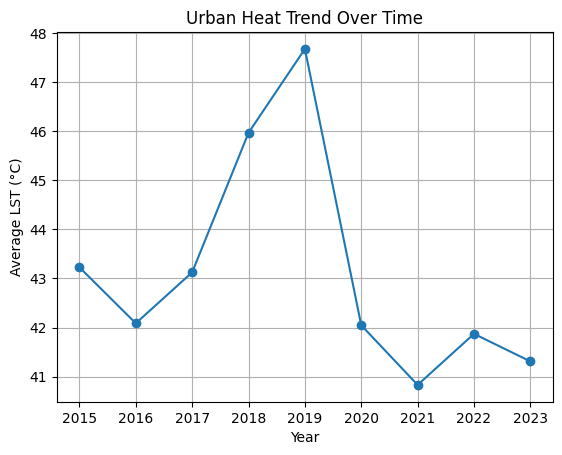

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df_time['year'], df_time['LST'], marker='o')
plt.xlabel("Year")
plt.ylabel("Average LST (°C)")
plt.title("Urban Heat Trend Over Time")
plt.grid()
plt.show()

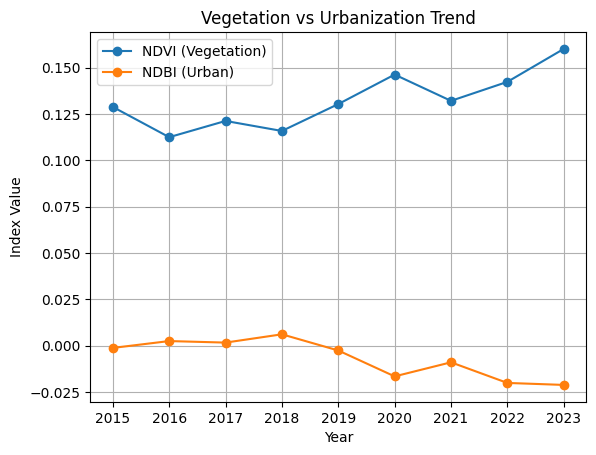

In [ ]:
plt.plot(df_time['year'], df_time['NDVI'], label='NDVI (Vegetation)', marker='o')
plt.plot(df_time['year'], df_time['NDBI'], label='NDBI (Urban)', marker='o')

plt.xlabel("Year")
plt.ylabel("Index Value")
plt.title("Vegetation vs Urbanization Trend")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print(df_time.corr())

           LST      NDBI      NDVI      year
LST   1.000000  0.559313 -0.407407 -0.338391
NDBI  0.559313  1.000000 -0.937314 -0.844608
NDVI -0.407407 -0.937314  1.000000  0.796598
year -0.338391 -0.844608  0.796598  1.000000


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_time[['year']]
y = df_time['LST']

model = LinearRegression()
model.fit(X, y)

future_years = np.array([[2025], [2026], [2027]])
predictions = model.predict(future_years)

print(predictions)

[41.44611652 41.1659427  40.88576888]


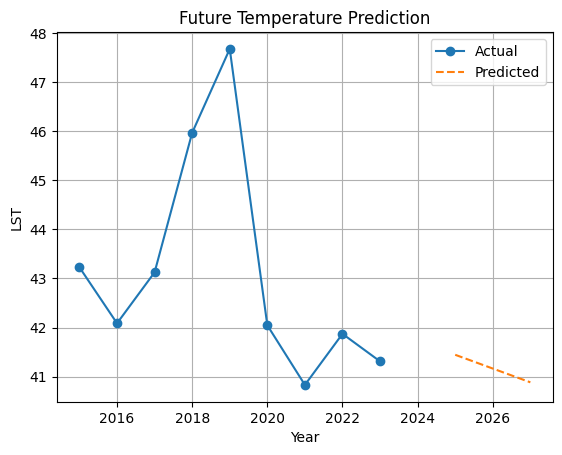

In [ ]:
plt.plot(df_time['year'], df_time['LST'], label='Actual', marker='o')
plt.plot(future_years, predictions, label='Predicted', linestyle='dashed')

plt.xlabel("Year")
plt.ylabel("LST")
plt.title("Future Temperature Prediction")
plt.legend()
plt.grid()
plt.show()

In [ ]:
samples_dense = lst.addBands(ndvi).addBands(ndbi).sample(
    region=roi,
    scale=30,
    numPixels=3000,   # more points = better hotspot detection
    geometries=True
)

In [ ]:
data_dense = samples_dense.getInfo()

records = []
for f in data_dense['features']:
    props = f['properties']
    coords = f['geometry']['coordinates']

    props['lon'] = coords[0]
    props['lat'] = coords[1]

    records.append(props)

df_geo = pd.DataFrame(records)
df_geo.head()

,LST,NDBI,NDVI,lon,lat
0,40.267016,-0.005793,0.224999,77.423022,28.594708
1,41.453069,0.031274,0.163369,77.466581,28.415560
2,38.881009,-0.049121,0.198954,77.209182,28.501620
3,37.737681,-0.173365,0.345331,77.465376,28.448069
4,40.613945,-0.024746,0.167782,77.233329,28.858485


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Features: spatial + temperature
X = df_geo[['lat', 'lon', 'LST']]

# Normalize
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.5, min_samples=10).fit(X_scaled)

df_geo['cluster'] = db.labels_

In [ ]:
hotspots = df_geo.groupby('cluster')['LST'].mean().sort_values(ascending=False)

print(hotspots)

cluster
 0    41.497934
-1    38.900357
Name: LST, dtype: float64


In [ ]:
import folium

m = folium.Map(location=[28.6, 77.2], zoom_start=10)

for _, row in df_geo.iterrows():
    color = 'red' if row['cluster'] == hotspots.index[0] else 'blue'

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=3,
        color=color,
        fill=True
    ).add_to(m)

m

In [ ]:
from folium.plugins import HeatMap

heat_data = df_geo[['lat', 'lon', 'LST']].values.tolist()

HeatMap(heat_data).add_to(m)

m